# SME Molecular Attribution Visualization

This notebook uses the PoCo ensemble to run SME fragment attribution for polymer SMILES, then overlays fragment contribution scores on RDKit molecular structure drawings.

IMPORTANT: Before running this notebook, make sure to use `src/finetune/finetune.py` to train the task head for inference.

In [1]:
import math
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D, rdDepictor
from rdkit.Geometry import Point2D
import io
from PIL import Image
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('style.mplstyle')
cmap = LinearSegmentedColormap.from_list(
    "sme_diverging",
    ["#3F9AAE", "#e8f7ff", "#F96E5B"],
)
BLUE = "#2e8396"
RED = "#c41803"


def _atom_radius_in_pixels(drawer, conf, atom_idx, radius):
    center = drawer.GetDrawCoords(atom_idx)
    pos = conf.GetAtomPosition(atom_idx)
    edge = drawer.GetDrawCoords(Point2D(pos.x + radius, pos.y))
    dx = edge.x - center.x
    dy = edge.y - center.y
    return (dx * dx + dy * dy) ** 0.5


def _orient_conformer(mol, rotate_deg=0, mirror=False):
    conf = mol.GetConformer()
    if not (rotate_deg or mirror):
        return conf

    coords = [conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())]
    cx = sum(p.x for p in coords) / len(coords)
    cy = sum(p.y for p in coords) / len(coords)

    if mirror:
        for i, p in enumerate(coords):
            conf.SetAtomPosition(i, (p.x, 2 * cy - p.y, p.z))

    if rotate_deg:
        theta = math.radians(float(rotate_deg))
        cos_t, sin_t = math.cos(theta), math.sin(theta)
        for i in range(mol.GetNumAtoms()):
            p = conf.GetAtomPosition(i)
            x, y = p.x - cx, p.y - cy
            conf.SetAtomPosition(
                i,
                (x * cos_t - y * sin_t + cx, x * sin_t + y * cos_t + cy, p.z),
            )
    return conf


def draw_molecule_image(mol, width, height, mol_scale=1.0, rotate_deg=0, mirror=False):
    rdDepictor.Compute2DCoords(mol)
    conf = _orient_conformer(mol, rotate_deg=rotate_deg, mirror=mirror)

    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    opt = drawer.drawOptions()
    opt.fixedBondLength = 35 * mol_scale
    opt.bondLineWidth = 2.5 * mol_scale
    opt.fixedFontSize = int(30 * mol_scale)
    opt.additionalAtomLabelPadding = 0.1
    opt.padding = 0.0
    opt.useBWAtomPalette()
    opt.setBackgroundColour((1, 1, 1, 0))

    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
    drawer.FinishDrawing()
    img = Image.open(io.BytesIO(drawer.GetDrawingText())).convert('RGBA')
    return img, drawer, conf


def plot_attribution(
    smiles, atom_groups, scores,
    figsize=(8, 4),
    mol_scale=1.0,
    rotate_deg=0,
    mirror=False,
    halo_radius=0.5,
    bond_width_ratio=0.6,
    vmax=None,
    show_colorbar=False,
    show_values=True,
    canvas_ppi=300,
    dpi=100,
):
    w = int(round(figsize[0] * canvas_ppi))
    h = int(round(figsize[1] * canvas_ppi))

    mol = Chem.MolFromSmiles(smiles)
    img, drawer, conf = draw_molecule_image(
        mol, w, h, mol_scale=mol_scale, rotate_deg=rotate_deg, mirror=mirror
    )
    vmax = vmax or max(abs(score) for score in scores)
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax, clip=True)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(img, extent=(0, w, h, 0), zorder=2)
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis('off')

    if show_colorbar:
        mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        mappable.set_array([])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='4%', pad=0.0)
        cbar = fig.colorbar(mappable, cax=cax)
        cbar.set_label('Attribution')
        cbar.ax.yaxis.set_label_position('left')
        cbar.ax.tick_params()
        cbar.outline.set_visible(False)

    for atoms, score in zip(atom_groups, scores):
        if score is None or not atoms:
            continue

        color = cmap(norm(score))
        label_color = BLUE if score < 0 else RED
        atom_centers = []
        atom_radii_px = []
        aset = set(atoms)

        for atom_idx in atoms:
            center = drawer.GetDrawCoords(atom_idx)
            atom_centers.append((center.x, center.y))
            radius_px = _atom_radius_in_pixels(drawer, conf, atom_idx, halo_radius)
            atom_radii_px.append(radius_px)

        mean_atom_radius_px = sum(atom_radii_px) / len(atom_radii_px)
        bond_shadow_width_px = 2.0 * mean_atom_radius_px * bond_width_ratio
        bond_shadow_width_pt = bond_shadow_width_px * 72.0 / canvas_ppi

        cx = sum(x for x, _ in atom_centers) / len(atom_centers)
        cy = sum(y for _, y in atom_centers) / len(atom_centers)

        for bond in mol.GetBonds():
            begin = bond.GetBeginAtomIdx()
            end = bond.GetEndAtomIdx()
            if begin not in aset or end not in aset:
                continue
            p1 = drawer.GetDrawCoords(begin)
            p2 = drawer.GetDrawCoords(end)
            ax.plot(
                [p1.x, p2.x], [p1.y, p2.y], color=color,
                linewidth=bond_shadow_width_pt, solid_capstyle='round', zorder=1,
            )

        for (center_x, center_y), radius_px in zip(atom_centers, atom_radii_px):
            ax.add_patch(
                patches.Circle(
                    (center_x, center_y), radius_px,
                    facecolor=color, edgecolor='none', zorder=1,
                )
            )

        if show_values:
            ax.text(
                cx, cy, f'${score:.3f}$',
                ha='center', va='center', color=label_color, zorder=3,
                path_effects=[pe.withStroke(linewidth=3, foreground='white')],
            )

    return fig, ax


Canonicalized SMILES: [*]CC([*])c1ccncc1
Predicted Tg: 79.44 ± 32.43


SME chunks: 100%|██████████| 1/1 [00:00<00:00, 42.80it/s]


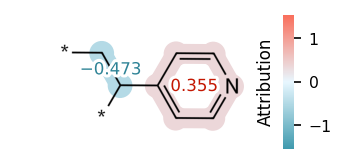

In [2]:
from psmiles import PolymerSmiles as PS

import sys
sys.path.append('../src/')

from utils import run_sme
from inference import get_ensemble_model

# smiles = '[*]CC([*])CCC'
# smiles = '[*]CCC(=O)NCCC[*]'
smiles = '[*]CC([*])c1ccncc1'

# Specify the task name corresponding to the model checkpoint you want to use
task_name = 'Tg'
model, tokenizer = get_ensemble_model(
    checkpoint_path='../checkpoints/OPC/PoCo',
    task_name=task_name,
)
smiles = PS(smiles).canonicalize.psmiles
print(f"Canonicalized SMILES: {smiles}")

enc = tokenizer(smiles, return_tensors='pt', return_token_type_ids=False)
pred, std = model(**enc, inverse=True, return_std=True)
print(f"Predicted {task_name}: {pred.item():.2f} ± {std.item():.2f}")

df_occurrence, _ = run_sme(
    smiles_list=[smiles],
    tokenizer=tokenizer,
    model=model,
    method='gram',
    device='cpu',
    intra_mol_mean=False,
    return_stats=False,
)
frag_labels = df_occurrence['fragment'].tolist()
scores = df_occurrence['delta'].tolist()
atom_groups = df_occurrence['atom_group'].apply(eval).tolist()

fig, ax = plot_attribution(
    smiles, atom_groups, scores,
    figsize=(2.4, 1.2),
    mol_scale=1.9,
    # rotate_deg=3.5,
    rotate_deg=172,
    mirror=True,
    vmax=1.54,
    show_colorbar=True,
    show_values=True,
    dpi=150,
)

# plt.savefig(f"sme_results/P4VP_{task_name}.svg")
plt.show()